Copyright (c) Microsoft Corporation. All rights reserved.

Licensed under the MIT License.

![Impressions](https://PixelServer20190423114238.azurewebsites.net/api/impressions/MachineLearningNotebooks/how-to-use-azureml/monitor-models/data-drift/drift-on-aks.png)

# Monitor data drift on models deployed to Azure Kubernetes Service 

In this tutorial, you will setup a data drift monitor on a toy model that predicts elevation based on a few weather factors which will send email alerts if drift is detected.

## Prerequisites
If you are using an Azure Machine Learning Compute instance, you are all set. Otherwise, go through the [configuration notebook](../../../configuration.ipynb) first if you haven't already established your connection to the AzureML Workspace.

In [1]:
# Check core SDK version number
import azureml.core

print('SDK version:', azureml.core.VERSION)

SDK version: 1.0.69


## Initialize Workspace

Initialize a workspace object from persisted configuration.

In [2]:
from azureml.core import Workspace

ws = Workspace.from_config()
ws

Workspace.create(name='Azure-ML', subscription_id='60582a10-b9fd-49f1-a546-c4194134bba8', resource_group='copetersRG')

## Setup training dataset and model

Setup the training dataset and model in preparation for deployment to the Azure Kubernetes Service. 

The next few cells will:
  * get the default datastore and upload the `training.csv` dataset to the datastore
  * create and register the dataset 
  * register the model with the dataset
  
See the `setup.py` script in this folder for details on how `training.csv` and `elevation-regression-model.pkl` are created. If you train your model in Azure ML using a Dataset, it will be automatically captured when registering the model from the run. 

In [4]:
# use default datastore
dstore = ws.get_default_datastore()

# upload weather data
dstore.upload('training-dataset', 'drift-on-aks-data', overwrite=True, show_progress=False);

In [5]:
from azureml.core import Dataset

# create dataset 
dset = Dataset.Tabular.from_delimited_files(dstore.path('drift-on-aks-data/training.csv'))
# register dataset
#dset = dset.register(ws, 'drift-demo-dataset')
# get the dataset by name from the workspace
dset = Dataset.get_by_name(ws, 'drift-demo-dataset')

In [6]:
from azureml.core.model import Model

# register the model
model = Model.register(model_path='elevation-regression-model.pkl',
                       model_name='elevation-regression-model.pkl',
                       tags={'area': "weather", 'type': "linear regression"},
                       description='Linear regression model to predict elevation based on the weather',
                       workspace=ws,
                       datasets=[(Dataset.Scenario.TRAINING, dset)]) # need to register the dataset with the model

Registering model elevation-regression-model.pkl


## Create the infernece config

Create the environment and inference config from the `myenv.yml` and `score.py` files. Notice the [Model Data Collector](https://docs.microsoft.com/azure/machine-learning/service/how-to-enable-data-collection) code included in the scoring script. This dependency is currently required to collect model data, but will be removed in the near future as data collection in Azure Machine Learning webservice endpoints is automated. 

In [7]:
from azureml.core import Environment

# create the environment from the yml file 
env = Environment.from_conda_specification(name='deploytocloudenv', file_path='myenv.yml')

In [8]:
from azureml.core.model import InferenceConfig

# create an inference config, combining the environment and entry script 
inference_config = InferenceConfig(entry_script='score.py', environment=env)

## Create the AKS compute target

Create an Azure Kubernetes Service compute target to deploy the model to. 

In [9]:
from azureml.core.compute import AksCompute, ComputeTarget

# Use the default configuration (you can also provide parameters to customize this).
# For example, to create a dev/test cluster, use:
# prov_config = AksCompute.provisioning_configuration(cluster_purpose = AksCompute.ClusterPurpose.DEV_TEST)
prov_config = AksCompute.provisioning_configuration()

aks_name = 'drift-aks'

# Create the cluster
try:
    aks_target = ws.compute_targets[aks_name]
except:
    aks_target = ComputeTarget.create(workspace = ws,
                                      name = aks_name,
                                      provisioning_configuration = prov_config)

    # Wait for the create process to complete
    aks_target.wait_for_completion(show_output = True)

Creating................................................................................................................................................................
SucceededProvisioning operation finished, operation "Succeeded"


## Deploy the model to AKS 

Deploy the model as a webservice endpoint. Be sure to enable the `collect_model_data` flag so that serving data is collected in blob storage for use by the data drift capability.

In [10]:
from azureml.core.webservice import AksWebservice, Webservice
from azureml.exceptions import WebserviceException

deployment_config = AksWebservice.deploy_configuration(cpu_cores=1, memory_gb=1)
service_name = 'drift-aks-service'

service = Model.deploy(ws, service_name, [model], inference_config, deployment_config, aks_target)

service.wait_for_deployment(True)
print(service.state)

Running.................
SucceededAKS service creation operation finished, operation "Succeeded"
Healthy


In [11]:
service.update(collect_model_data=True)

## Run recent weather data through the webservice 

The below cells take the past 2 days of weather data, filter and transform using the same processes as the training dataset, and runs the data through the service.

In [12]:
from datetime import datetime, timedelta
from azureml.opendatasets import NoaaIsdWeather

start = datetime.today() - timedelta(days=2)
end = datetime.today()

isd = NoaaIsdWeather(start, end)

df = isd.to_pandas_dataframe().fillna(0)
df = df[df['stationName'].str.contains('FLORIDA', regex=True, na=False)]

X_features = ['latitude', 'longitude', 'temperature', 'windAngle', 'windSpeed']
y_features = ['elevation']

X = df[X_features]
y = df[y_features]

ActivityStarted, to_pandas_dataframe
ActivityStarted, to_pandas_dataframe_in_worker
Target paths: ['/year=2019/month=10/']
Looking for parquet files...
Reading them into Pandas dataframe...
Reading ISDWeather/year=2019/month=10/part-00122-tid-3574239015665017802-f2b8a0bc-5904-41f7-aee8-af478cb02ec8-1838762.c000.snappy.parquet under container isdweatherdatacontainer
Done.
ActivityCompleted: Activity=to_pandas_dataframe_in_worker, HowEnded=Success, Duration=25058.33 [ms]
ActivityCompleted: Activity=to_pandas_dataframe, HowEnded=Success, Duration=25076.51 [ms]


In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26 entries, 3208044 to 3232295
Data columns (total 5 columns):
latitude       26 non-null float64
longitude      26 non-null float64
temperature    26 non-null float64
windAngle      26 non-null float64
windSpeed      26 non-null float64
dtypes: float64(5)
memory usage: 1.2 KB


In [14]:
import json

today_data = json.dumps({'data': X.values.tolist()})

data_encoded = bytes(today_data, encoding='utf8')
prediction = service.run(input_data=data_encoded)
print(prediction)

[[-4.011386447699408], [-2.95798632577646], [14.22317277840979], [-3.351006461363255], [-5.391543723041224], [13.36971556402942], [-3.351006461363255], [-3.351006461363255], [-3.351006461363255], [-3.351006461363255], [-3.351006461363255], [-3.351006461363255], [-3.351006461363255], [41.54081329555177], [-3.351006461363255], [7.865931002514543], [10.959868386115446], [-4.967947688605221], [5.099904733371233], [4.506941690241774], [4.833698843660656], [6.213856119002472], [7.400936166300099], [50.12655837669962], [8.261259060178801], [8.06131615263621]]


## Create an Azure Machine Learning Compute cluster

The data drift capability needs a compute target for computing drift and other data metrics. 

In [15]:
from azureml.core.compute import AmlCompute, ComputeTarget

compute_name = 'cpu-cluster'

if compute_name in ws.compute_targets:
    compute_target = ws.compute_targets[compute_name]
    if compute_target and type(compute_target) is AmlCompute:
        print('found compute target. just use it. ' + compute_name)
else:
    print('creating a new compute target...')
    provisioning_config = AmlCompute.provisioning_configuration(vm_size='STANDARD_D3_V2', min_nodes=0, max_nodes=2)

    # create the cluster
    compute_target = ComputeTarget.create(ws, compute_name, provisioning_config)

    # can poll for a minimum number of nodes and for a specific timeout.
    # if no min node count is provided it will use the scale settings for the cluster
    compute_target.wait_for_completion(show_output=True, min_node_count=None, timeout_in_minutes=20)

    # For a more detailed view of current AmlCompute status, use get_status()
    print(compute_target.get_status().serialize())

found compute target. just use it. cpu-cluster


## Wait 10 minutes

From the Model Data Collector, it can take up to (but usually less than) 10 minutes for data to arrive in your blob storage account. Wait 10 minutes to ensure cells below will run.

In [16]:
import time

time.sleep(600)

## Create and update the data drift object

In [20]:
from azureml.datadrift import DataDriftDetector, AlertConfiguration

services = [service_name]
start = datetime.now() - timedelta(days=2)
feature_list = X_features
alert_config = AlertConfiguration(['user@contoso.com'])

try:
    monitor = DataDriftDetector.create(ws, model.name, model.version, services, 
                                                  frequency='hour',
                                                   interval=
                                                  schedule_start=datetime.utcnow() + timedelta(days=1), 
                                                  alert_config=alert_config, 
                                                  compute_target_name='gpu-cluster')
except KeyError:
    monitor = DataDriftDetector.get(ws, model.name, model.version)
    
monitor

{'_workspace': Workspace.create(name='Azure-ML', subscription_id='60582a10-b9fd-49f1-a546-c4194134bba8', resource_group='copetersRG'), '_frequency': 'Day', '_schedule_start': datetime.datetime(2019, 10, 18, 5, 45, 12, 34898, tzinfo=<FixedOffset '+00:00'>), '_schedule_id': None, '_interval': 1, '_state': 'Disabled', '_alert_config': {'email_addresses': ['user@contoso.com']}, '_type': 'ModelBased', '_id': '265c9c4a-7630-49fd-be2b-d116f3a1d151', '_model_name': 'elevation-regression-model.pkl', '_model_version': 2, '_services': ['drift-aks-service'], '_compute_target_name': 'gpu-cluster', '_drift_threshold': 0.2, '_baseline_dataset_id': '00000000-0000-0000-0000-000000000000', '_target_dataset_id': '00000000-0000-0000-0000-000000000000', '_feature_list': None, '_latency': 0, '_name': None, '_client': <azureml.datadrift._restclient.datadrift_client.DataDriftClient object at 0x7fd01963f590>, '_logger': <_TelemetryLoggerContextAdapter azureml.datadrift._logging._telemetry_logger.azureml.datadr

In [30]:
# many monitor settings can be updated 
monitor = monitor.update(drift_threshold = 0.1)
monitor.update(compute_target_name='gpu-cluster')

alert_config = AlertConfiguration(['cody.peterson@microsoft.com'])
monitor.update(alert_config=alert_config)

monitor

{'_workspace': Workspace.create(name='Azure-ML', subscription_id='60582a10-b9fd-49f1-a546-c4194134bba8', resource_group='copetersRG'), '_frequency': 'Day', '_schedule_start': datetime.datetime(2019, 10, 18, 5, 45, 12, 34898, tzinfo=<FixedOffset '+00:00'>), '_schedule_id': None, '_interval': 1, '_state': 'Disabled', '_alert_config': {'email_addresses': ['cody.peterson@microsoft.com']}, '_type': 'ModelBased', '_id': '265c9c4a-7630-49fd-be2b-d116f3a1d151', '_model_name': 'elevation-regression-model.pkl', '_model_version': 2, '_services': ['drift-aks-service'], '_compute_target_name': 'gpu-cluster', '_drift_threshold': 0.1, '_baseline_dataset_id': '00000000-0000-0000-0000-000000000000', '_target_dataset_id': '00000000-0000-0000-0000-000000000000', '_feature_list': None, '_latency': 0, '_name': None, '_client': <azureml.datadrift._restclient.datadrift_client.DataDriftClient object at 0x7fd01963f590>, '_logger': <_TelemetryLoggerContextAdapter azureml.datadrift._logging._telemetry_logger.azu

## Run the monitor on today's scoring data

Perform a data drift run on the data sent to the service earlier in this notebook. If you set your email address in the alert configuration and the drift threshold <=0.1 you should recieve an email alert to drift from this run.

Wait for the run to complete before getting the results. 

In [31]:
now = datetime.utcnow()
target_date = datetime(now.year, now.month, now.day)
run = monitor.run(target_date, services, feature_list=feature_list, compute_target_name='gpu-cluster')

In [25]:
run.wait_for_completion(wait_post_processing=True); time.sleep(60)

AttributeError: 'str' object has no attribute 'wait_for_completion'

## Get and view results and metrics

For enterprise workspaces, the UI in the Azure Machine Learning studio can be used. Otherwise, the metrics can be queried in Python and plotted. 

In [36]:
results, metrics = monitor.get_output(start, now)

In [37]:
results

[{'drift_type': 'ModelBased',
  'service_name': 'drift-aks-service',
  'result': [{'has_drift': True,
    'drift_threshold': 0.1,
    'datetime': datetime.datetime(2019, 10, 17, 0, 0),
    'model_name': 'elevation-regression-model.pkl',
    'model_version': 2}]}]

In [38]:
metrics

[{'drift_type': 'ModelBased',
  'service_name': 'drift-aks-service',
  'metrics': [{'schema_version': '0.1',
    'datetime': datetime.datetime(2019, 10, 17, 0, 0),
    'model_name': 'elevation-regression-model.pkl',
    'model_version': 2,
    'column_metrics': [{'latitude': [{'name': 'wasserstein_distance',
        'value': 23.057174300987253},
       {'name': 'energy_distance', 'value': 3.5304052071807277},
       {'name': 'datadrift_contribution', 'value': 19.0}]},
     {'windAngle': [{'name': 'wasserstein_distance',
        'value': 99.29246461124922},
       {'name': 'energy_distance', 'value': 8.207136252980012},
       {'name': 'datadrift_contribution', 'value': 6.0}]},
     {'longitude': [{'name': 'wasserstein_distance',
        'value': 20.47522418986851},
       {'name': 'energy_distance', 'value': 3.3090188785982226},
       {'name': 'datadrift_contribution', 'value': 21.0}]},
     {'windSpeed': [{'name': 'wasserstein_distance',
        'value': 2.215769350800887},
       {'

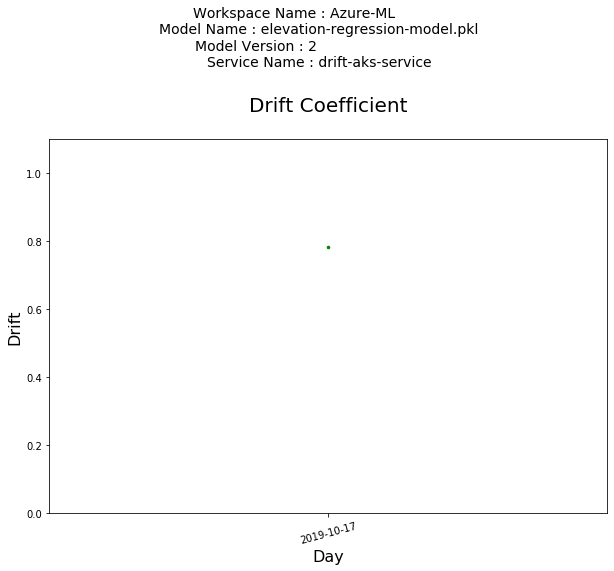

In [29]:
drift_plots = monitor.show()

## Enable the monitor's pipeline schedule

Turn on a scheduled pipeline which will anlayze the serving dataset for drift. 

In [ ]:
monitor.enable_schedule()

## Next steps

  * See [our documentation](https://aka.ms/datadrift/aks) or [Python SDK reference](https://docs.microsoft.com/python/api/overview/azure/ml/intro)
  * [Send requests or feedback](mailto:driftfeedback@microsoft.com) on data drift directly to the team
  * Please open issues with data drift here on GitHub or on StackOverflow if others are likely to run into the same issue